# Modellvergleich — Verteilungsplots & Ergebnis-Makros

Erzeugt aus `data/model_comparison/results.csv` die zwei kombinierten Violin-/Boxplots
(`plots/model_comparison_stationary.pgf`, `_transient.pgf`) für Kapitel 2 und exportiert
die besten MAE-Werte je Architektur als LaTeX-Makros nach `results/model_comparison.tex`
(Tabelle \ref{tab:model_performance}). Styling über *thesis_style* (`fig_width` +
`SET2`), Speichern über den `plot_store`/`res_store` — konsistent zu den übrigen Notebooks.

In [15]:
IS_FINAL = True

In [16]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, ".."))

base_dir    = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir    = base_dir / "data" / "mill_data"
plot_dir    = base_dir / "plots"
results_dir = base_dir / "results"
file_name   = "model_comparison.csv"

for _d in (plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True)

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts
from src.utils import run_registry as rr
from src.utils import latex_export as lx

w = ts.fig_width()          # Diss-Stil (Spines aus, Farbzyklus) + Textbreite in Zoll

fig_cfg    = rr.RunConfig({"source": file_name, "mae_filter": 0.1})
plot_store = rr.OutputStore(plot_dir, "model_comparison")   # -> plots/model_comparison_*.pgf
res_store  = rr.OutputStore(results_dir)                    # -> results/model_comparison.tex

## Daten laden

In [18]:
df = pd.read_csv(data_dir / file_name)
df.columns = df.columns.str.strip()

# Beschriftung der Architekturen (feste Reihenfolge fuer Plots und Tabelle)
translate = {
    'linear_regression': 'Lineare \nRegression',
    'lasso_regression':  'Lasso-\nRegression',
    'static_mlp':        'MLP \n(statisch)',
    'dynamic_mlp':       'MLP \n(dynamisch)',
    'conv1d':            'CNN',
    'lstm':              'LSTM',
}

# Plots: starke Ausreisser ausblenden, damit die Verteilungen lesbar bleiben
df_plot = df[(df['test_mae_static'] < 0.1) & (df['test_mae_transient'] < 0.1)].copy()
df_plot['model_key'] = df_plot['model_key'].map(translate)

## Verteilungsplots (Violin + Box)

Beide Plots identisch aufgebaut; Farben der Violinen aus `ts.SET2`, Box-Overlay in
`ts.C["box"]`. Speichern über den `plot_store`.

c:\git\process_optimization_concept_drift\venv_311\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)
c:\git\process_optimization_concept_drift\venv_311\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


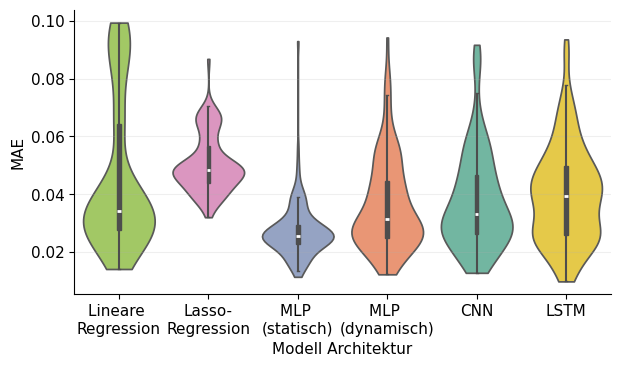

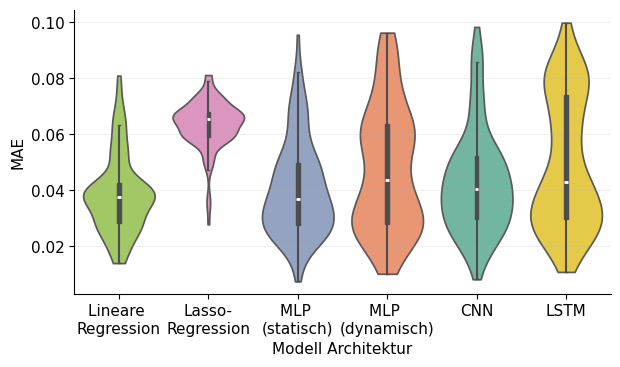

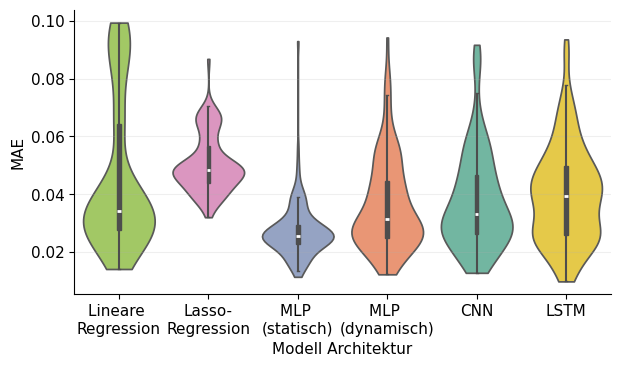

In [19]:
def violin_box(y_col, name):
    fig, ax = plt.subplots(figsize=(w, w * 0.6))
    ts.violin_box(df_plot, 'model_key', y_col, order=list(translate.values()),
                  palette=ts.SET2, box_width=0.04, ax=ax)
    ax.set_ylabel('MAE')
    ax.set_xlabel('Modell Architektur')
    fig.tight_layout()
    plot_store.save_figure(fig, name, fig_cfg, final=IS_FINAL,
                           savefig_kwargs={"bbox_inches": None})
    return fig

violin_box('test_mae_static',    'stationary')
violin_box('test_mae_transient', 'transient')


## Ergebnis-Makros für die Tabelle

Bester MAE je Architektur (aus den *ungefilterten* Daten) und relative Abweichung
$\Delta$ zum jeweils besten Modell desselben Datensatzes; Export als `\newcommand`-Makros.

In [20]:
# Macro-Tokens je Architektur (nur Buchstaben -> LaTeX-\newcommand-tauglich)
MODEL_TOKENS = {
    'linear_regression': 'LinReg',
    'lasso_regression':  'Lasso',
    'static_mlp':        'MlpStatic',
    'dynamic_mlp':       'MlpDynamic',
    'conv1d':            'Cnn',
    'lstm':              'Lstm',
}

best_stat  = df.groupby('model_key')['test_mae_static'].min()
best_trans = df.groupby('model_key')['test_mae_transient'].min()
abs_stat, abs_trans = best_stat.min(), best_trans.min()

def fmt_delta(pct):
    if pct <= 1e-9:                       # bestes Modell der Kategorie
        return r'\textbf{0{,}0\%}'
    return '+' + f'{pct:.1f}'.replace('.', '{,}') + r'\%'

mx = lx.MacroExport("automatisch erzeugt aus model_comparison.ipynb - nicht editieren")
mx.comment("Bester MAE je Architektur und Abweichung zum Kategoriebesten")
for key, tok in MODEL_TOKENS.items():
    d_stat  = (best_stat[key]  - abs_stat)  / abs_stat  * 100
    d_trans = (best_trans[key] - abs_trans) / abs_trans * 100
    mx.num(f"mc{tok}MaeStat",    best_stat[key],  5)
    mx.raw(f"mc{tok}DeltaStat",  fmt_delta(d_stat))
    mx.num(f"mc{tok}MaeTrans",   best_trans[key], 5)
    mx.raw(f"mc{tok}DeltaTrans", fmt_delta(d_trans))

mx.save(res_store, "model_comparison", fig_cfg, final=IS_FINAL)

LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\model_comparison.tex

% automatisch erzeugt aus model_comparison.ipynb - nicht editieren

% Bester MAE je Architektur und Abweichung zum Kategoriebesten
\newcommand{\mcLinRegMaeStat}{0{,}01400}
\newcommand{\mcLinRegDeltaStat}{+87{,}7\%}
\newcommand{\mcLinRegMaeTrans}{0{,}01410}
\newcommand{\mcLinRegDeltaTrans}{+43{,}7\%}
\newcommand{\mcLassoMaeStat}{0{,}02783}
\newcommand{\mcLassoDeltaStat}{+273{,}3\%}
\newcommand{\mcLassoMaeTrans}{0{,}03205}
\newcommand{\mcLassoDeltaTrans}{+226{,}6\%}
\newcommand{\mcMlpStaticMaeStat}{0{,}00745}
\newcommand{\mcMlpStaticDeltaStat}{\textbf{0{,}0\%}}
\newcommand{\mcMlpStaticMaeTrans}{0{,}01140}
\newcommand{\mcMlpStaticDeltaTrans}{+16{,}2\%}
\newcommand{\mcMlpDynamicMaeStat}{0{,}01017}
\newcommand{\mcMlpDynamicDeltaStat}{+36{,}5\%}
\newcommand{\mcMlpDynamicMaeTrans}{0{,}01226}
\newcommand{\mcMlpDynamicDeltaTrans}{+25{,}0\%}
\newcommand{\mcCnnMaeStat}{0{,}00822}
\newcommand{\mcCnnDeltaStat}{+

'C:\\git\\process_optimization_concept_drift\\results\\model_comparison.tex'